In [23]:
RANDOM_STATE = 2025
import os
import sys
# Get the absolute path of the current directory
current_dir = os.getcwd()

# Get the parent directory (project root)
parent_dir = os.path.dirname(current_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

In [24]:

import pandas as pd
import numpy as np
import gc

from data.dataset import MalwareDatasetLoader
from data.data_processing import split_out_targets, force_dense, preprocess_existing, preprocess_fit

RELOAD_DATA = False
if not RELOAD_DATA:
  try:
    print(df_features_train.head())
  except Exception as e:
    print("No dataframe.  Loading data...")
    RELOAD_DATA=True
if RELOAD_DATA:
  df_loader = MalwareDatasetLoader()

  df_train, df_val, df_test = df_loader.make_data_splits()
  
  df_features_train, df_y_train = split_out_targets(df_train)
  df_features_val, df_y_val = split_out_targets(df_val)
  df_features_test, df_y_test = split_out_targets(df_test)
  del df_loader
  gc.collect()


  proto service conn_state history  id.orig_p  id.resp_p  duration orig_bytes  \
0   tcp     NaN         S0       S    33856.0       23.0  3.143457        0.0   
1   tcp     NaN         S0       S    35075.0       23.0      -1.0       -1.0   
2   tcp     NaN         S0       S    54320.0       23.0  3.158696        0.0   
3   tcp     NaN         S0       S    52401.0       81.0      -1.0       -1.0   
4   tcp     NaN         S0       S    57418.0       23.0  3.086476        0.0   

  resp_bytes  missed_bytes  orig_pkts  orig_ip_bytes  resp_pkts  resp_ip_bytes  
0        0.0           0.0        3.0          180.0        0.0            0.0  
1       -1.0           0.0        1.0           40.0        0.0            0.0  
2        0.0           0.0        3.0          180.0        0.0            0.0  
3       -1.0           0.0        1.0           40.0        0.0            0.0  
4        0.0           0.0        3.0          180.0        0.0            0.0  


In [25]:
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix


def compute_metrics(classifier, df_features, df_y):
  print(f"Compute Metrics Start: {df_features.shape[0]}")
  predictions = classifier.predict(df_features)
  print("Compute Metrics End")

  acc = accuracy_score(df_y, predictions)
  f1 = f1_score(df_y, predictions)
  cm = confusion_matrix(df_y, predictions)

  print(f"Accuracy: {acc:.4f}")
  print(f"F1:       {f1:.4f}")
  #print(f"AUC:      {auc:.4f}")
  print("Confusion matrix:")
  print(cm)
  print()
  return classification_report(df_y, predictions, output_dict=True)


In [26]:

from numpy.random.mtrand import f
import sklearn
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC


In [27]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.cluster import MiniBatchKMeans
import numpy as np
from sklearn.metrics import classification_report

VERBOSE = False

def transform_kmeans(features, labels, kmeans_clusters_per_class):
    features_train_svm = []
    y_train_svm = []

    unique_labels = np.unique(labels["label"])
    print(unique_labels)
    for label in unique_labels:
        # Filter data for this specific class
        class_data = features[(labels['label'] == label).values]

        kmeans = MiniBatchKMeans(
            n_clusters=kmeans_clusters_per_class, 
            batch_size=4096,
            random_state=42,
            n_init="auto",
        )
    
        kmeans.fit(class_data)
        centers = kmeans.cluster_centers_

        # The cluster centers become our new "training examples"
        features_train_svm.append(centers)
        y_train_svm.append(np.full(centers.shape[0], label))

    features_final = np.vstack(features_train_svm)
    labels_final = np.concatenate(y_train_svm)
    return features_final, labels_final

class SvmClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self):
        super().__init__()
        self.classifier = None
    
    def predict(self, X):
        dense_X_transformed = force_dense(X)
        return self.classifier.predict(dense_X_transformed)

    def train(self, X_final, y_final, C, gamma, kernel):
        print(X_final.shape)

        self.classifier = SVC(
            kernel=kernel,
            C=C,
            gamma=gamma,
            max_iter=20_000_000,
        )
        
        self.classifier.fit(X_final, y_final)
        print(f"Iterations: {self.classifier.n_iter_}")



In [28]:
from typing import Optional
from data import dataset
from sklearn.preprocessing import PowerTransformer
from sklearn.base import TransformerMixin, OneToOneFeatureMixin
from data.data_processing import preprocess_fit

def p999(x):
    return x.quantile(0.999)
import gc

ANALYZE_DISTRIBUTIONS = False
if ANALYZE_DISTRIBUTIONS:
    numeric_features_df = df_features_train[dataset.NUMERIC_COLUMNS]
    gc.collect()
    result = numeric_features_df.agg(['min', 'max', p999])
    print(result)
    gc.collect()

    Xprime, preprocessor = preprocess_fit(numeric_features_df, include_onehot=False, quantile_clipping=False, power_transform=True)
    gc.collect()
    new_columns = preprocessor.get_feature_names_out()
    gc.collect()

    # Create a temporary DataFrame for analysis
    df_post = pd.DataFrame(Xprime)#, columns=new_columns)
    result2 = df_post.agg(['min', 'max', 'mean', 'std', p999])
    gc.collect()
    print(result2)


In [ ]:

ALL_SVM_KERNEL_TYPES = ['poly', 'linear', 'rbf', 'sigmoid']

# By default this will keep existing results when starting a new run.
# Set this to true to remove old training results.
RESET_RESULTS_LIST=False
try:
  test = final_results[0]
except Exception as e:
  RESET_RESULTS_LIST = True
if RESET_RESULTS_LIST:
  final_results = []

SINGLE_TRAIN = False
if SINGLE_TRAIN:
  C_values = [1000] #np.logspace(start=3, stop=4, num=3),
  gamma_values = [0.31622776601683794] #np.logspace(start=-1, stop=0, num=5),
  kernels=['rbf'] #ALL_SVM_KERNEL_TYPES,
  clusters_per_class=1000
else:
  C_values = np.logspace(start=-3, stop=6, num=7)
  gamma_values = np.logspace(start=-3, stop=6, num=7)
  kernels = ALL_SVM_KERNEL_TYPES
  clusters_per_class = 1000

# Speed up hyperparameter tuning, by doing kmeans-based dataset compression
# only once.
print("Starting KMeans")
X_transformed, preprocessor = preprocess_fit(df_features_train)
X_kmeans, y_kmeans = transform_kmeans(X_transformed, df_y_train, clusters_per_class)
print("Finished KMeans")
X_validation_transformed = force_dense(preprocess_existing(df_features_val, preprocessor))
for kernel in kernels:
  for c in C_values:
    for gamma in gamma_values:
      print(f"Experiment: {kernel} - {c}")
      classifier = SvmClassifier()
      classifier.train(X_kmeans, y_kmeans, c, gamma, kernel)
      metrics = compute_metrics(classifier.classifier, X_validation_transformed, df_y_val)
      description = f"SVM: - {kernel} - {c} - {gamma}"
      print(description)
      print(f"Class 0: {metrics['0']['f1-score']}  - Class 1:  {metrics['1']['f1-score']}")
      print(f"Support vectors: {classifier.classifier.n_support_}")
      print(f"Percentage of training set: {np.sum(classifier.classifier.n_support_) / len(X_kmeans)}")
      
      final_results.append((classifier, metrics, (kernel, c, gamma), description))


Starting KMeans
Global feature space dimensionality: 265
[0 1]
Finished KMeans
Experiment: poly - 1000.0
(10000, 265)
Iterations: [6171]
Compute Metrics Start: 3751650
Compute Metrics End
Accuracy: 0.9011
F1:       0.8759
Confusion matrix:
[[2070731  364480]
 [   6737 1309702]]

SVM: - poly - 1000.0 - 0.1
Class 0: 0.9177391079666868  - Class 1:  0.8758729374267084
Support vectors: [889 882]
Percentage of training set: 0.1771
Experiment: poly - 1000.0
(10000, 265)
Iterations: [66742]
Compute Metrics Start: 3751650
Compute Metrics End
Accuracy: 0.9065
F1:       0.8819
Confusion matrix:
[[2091480  343731]
 [   6872 1309567]]

SVM: - poly - 1000.0 - 0.1778279410038923
Class 0: 0.9226650208676928  - Class 1:  0.8819413975042234
Support vectors: [858 854]
Percentage of training set: 0.1712
Experiment: poly - 1000.0
(10000, 265)


/home/craig-wilkinson/miniconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=20000000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Iterations: [20000000]
Compute Metrics Start: 3751650
Compute Metrics End
Accuracy: 0.9820
F1:       0.9749
Confusion matrix:
[[2374753   60458]
 [   7087 1309352]]

SVM: - poly - 1000.0 - 0.31622776601683794
Class 0: 0.9859779354630043  - Class 1:  0.9748552721657597
Support vectors: [639 644]
Percentage of training set: 0.1283
Experiment: poly - 1000.0
(10000, 265)
Iterations: [5356801]
Compute Metrics Start: 3751650
Compute Metrics End
Accuracy: 0.9820
F1:       0.9748
Confusion matrix:
[[2374582   60629]
 [   7028 1309411]]

SVM: - poly - 1000.0 - 0.5623413251903491
Class 0: 0.9859540140686149  - Class 1:  0.9748157346474698
Support vectors: [295 294]
Percentage of training set: 0.0589
Experiment: poly - 1000.0
(10000, 265)
Iterations: [8528325]
Compute Metrics Start: 3751650
Compute Metrics End
Accuracy: 0.9819
F1:       0.9747
Confusion matrix:
[[2374375   60836]
 [   7028 1309411]]

SVM: - poly - 1000.0 - 1.0
Class 0: 0.9859104341763737  - Class 1:  0.9747406284173141
Support ve

In [ ]:
print(metrics)

              precision    recall  f1-score   support

           0       1.00      0.87      0.93   2435211
           1       0.80      0.99      0.89   1316439

    accuracy                           0.91   3751650
   macro avg       0.90      0.93      0.91   3751650
weighted avg       0.93      0.91      0.91   3751650



In [ ]:
print(f"Support vectors: {classifier.classifier.n_support_}")
print(f"Percentage of training set: {np.sum(classifier.classifier.n_support_) / len(X_kmeans)}")

In [ ]:

max_avg_f1 = 0
for classifier, preprocessor, metrics, config, config_tuple, description in final_results:
    avg_f1 = (metrics['0']['f1-score'] + metrics['1']['f1-score'])/2
    if avg_f1 > max_avg_f1:
        max_avg_f1 = avg_f1
        max_f1_preprocessor = preprocessor
        max_f1_classifier = classifier

X_test_transformed = preprocess_existing(df_features_test, max_f1_preprocessor)

metrics = compute_metrics(max_f1_classifier, X_test_transformed, df_y_test)


SVM: - rbf - 1000.0 - 0.31622776601683794

Accuracy: 0.9910
F1:       0.9873
Confusion matrix:
[[2407423   27788]
 [   5828 1310611]]

SVM: - rbf - 1000 - 0.31622776601683794

Accuracy: 0.9916
F1:       0.9882
Confusion matrix:
[[2407586   27625]
 [   3771 1312668]]

SVM: - rbf - 1000 - 0.5623413251903491

Accuracy: 0.9916
F1:       0.9881
Confusion matrix:
[[2407630   27581]
 [   4061 1312378]]

SVM: - rbf - 1000 - 1.0

Accuracy: 0.9916
F1:       0.9881
Confusion matrix:
[[2407649   27562]
 [   3924 1312515]]



Searching for: poly
Kernel type: poly - max F1: 0.9835485718560368 - desc: SVM: - poly - 10000000.0 - 0.006812920690579608
Searching for: linear
Kernel type: linear - max F1: 0.9811003904293394 - desc: SVM: - linear - 4641.588833612782 - 0.0001
Searching for: rbf
Kernel type: rbf - max F1: 0.9878272674055734 - desc: SVM: - rbf - 4641.588833612782 - 0.46415888336127775
Searching for: sigmoid
Kernel type: sigmoid - max F1: 0.9805106058360689 - desc: SVM: - sigmoid - 215443.46900318866 - 0.0001


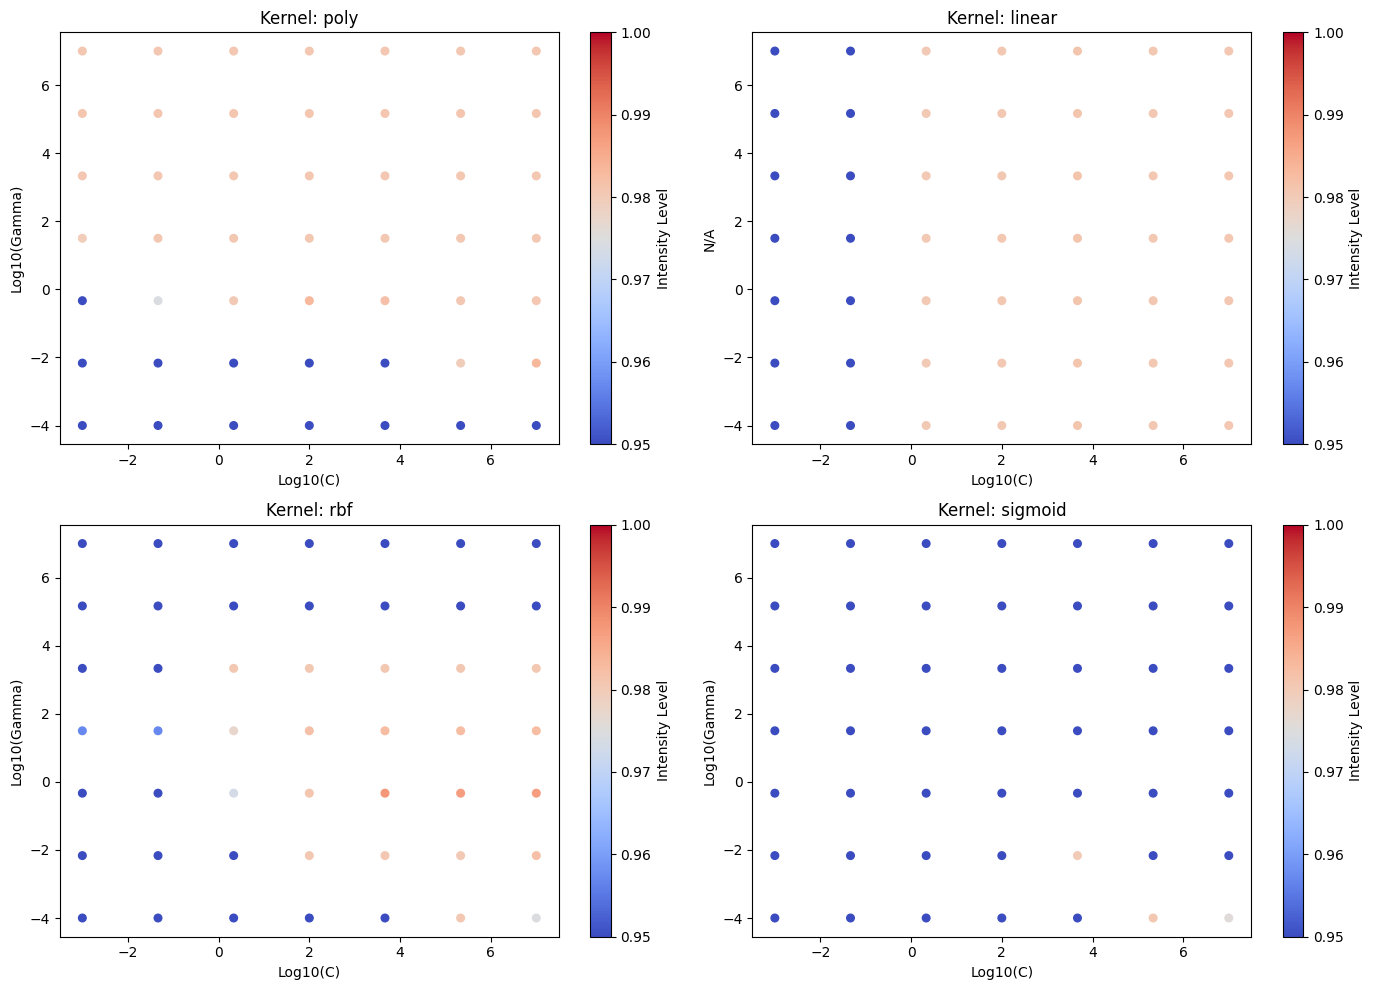

In [ ]:
import matplotlib.pyplot as plt
import math
def graph_results(result_type, results, kernel_types=None):
  if result_type == "SVM":
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
    
    # Flatten the 2x2 matrix of axes into a 1D list for easy iteration
    axes_flat = axes.flatten()
    assert kernel_types is not None
    for index, kernel_type in enumerate(kernel_types):
      print(f"Searching for: {kernel_type}")
      ax = axes_flat[index]

      x_dim_points = []
      y_dim_points = []
      labels = []
      max_f1 = 0
      max_f1_desc = ""
      # FIXME:
      for (classifier, metrics, config, expt_desc) in results:
        if config.kmeans_svm_config and result_type == 'SVM':
          is_correct_kernel = False
          for kernel in config.kmeans_svm_config.kernels:
            if f"- {kernel} -" in expt_desc and kernel == kernel_type:
              is_correct_kernel = True
          if not is_correct_kernel:
            continue
          for c in config.kmeans_svm_config.C:
            if f"- {c} -" in expt_desc:
              x_dim_points.append(math.log10(c))
              break
          for gamma in config.kmeans_svm_config.gamma:
            if f"- {gamma}" in expt_desc:
              y_dim_points.append(math.log10(gamma))
              break
          avg_f1 = (metrics['0']['f1-score'] + metrics['1']['f1-score'])/2
          if avg_f1 > max_f1:
            max_f1 = avg_f1
            max_f1_desc = expt_desc
          labels.append(avg_f1)
      print(f"Kernel type: {kernel_type} - max F1: {max_f1} - desc: {max_f1_desc}")
      sc = ax.scatter(x_dim_points, y_dim_points, c=labels, cmap='coolwarm', s=30, vmin=0.5, vmax=1.0)
      ax.set_title(f"Kernel: {kernel_type}")
      ax.set_xlabel("Log10(C)")
      ax.set_ylabel("Log10(Gamma)" if kernel_type != 'linear' else "N/A")
      cbar = plt.colorbar(sc)
      cbar.set_label('Intensity Level') # Optional label
  plt.tight_layout()
  plt.show()
  plt.show()

graph_results("SVM", final_results, kernel_types=ALL_SVM_KERNEL_TYPES)